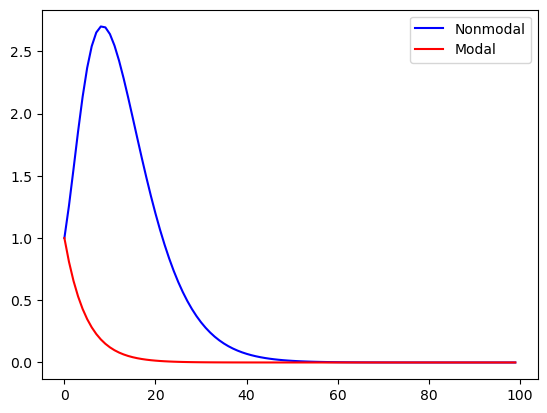

In [1435]:
import numpy as np 
import matplotlib.pyplot as plt

#s = np.random.normal(0, 0.1, 1000)
dim      = 100
growth1  = np.zeros((dim,1))
growth2  = np.zeros((dim,1))
a        = np.array([[0.9,0.4],[0.,0.9]])
x_0      = np.array([[1],[0]])
for tau in range(dim):
    G_tau    = np.linalg.matrix_power(a, tau)
    x_tau    = np.matmul(G_tau,x_0)
    h        = np.matmul(np.matrix(G_tau).getH(),G_tau)
    w,v      = np.linalg.eig(h)
    growth1[tau,:] = np.max(w)
    growth2[tau,:] = np.matmul(np.transpose(x_tau),x_tau)/np.matmul(np.transpose(x_0),x_0)

plt.figure()
plt.plot(growth1,'b', label='Nonmodal')
plt.plot(growth2,'r', label='Modal')
plt.legend()

In [1432]:
v[1,:]

matrix([[ 0.6463749 , -0.76301998]])

In [1412]:
mean         = 0
std          = 1 
x_record     = np.zeros((5000,2))
x_record[0,] = np.random.normal(mean, std, size=1)
std1         = np.zeros((100,2))
for count in range(100):
    for i in range(1,5000):
        x_record[i,] = a.dot(x_record[i-1,])+np.array([np.random.normal(mean, std, size=1),np.random.normal(mean, std, size=1)]).T
    std1[count,0] = np.std(x_record[:,0])
    std1[count,1] = np.std(x_record[:,1])
    
print(np.std(x_record[:,0]))
print(np.std(x_record[:,1]))

5.187491148283424
2.24334547653795


In [1392]:
np.std()

array([[-1.05926088],
       [-0.99656043]])

In [1413]:
residual      = x_record[1:,].T-a.dot(x_record[:4999,].T)
std           = 1
x_record2     = np.zeros((5000,2))
x_record2[0,] = np.random.normal(mean, std, size=2)
std2           = np.zeros((100,2))
for count in range(100):
    for i in range(1,5000):
        x_record2[i,] = a.dot(x_record2[i-1,])+residual[:,randrange(4999)].T
    std2[count,0] = np.std(x_record2[:,0])
    std2[count,1] = np.std(x_record2[:,1])

{'whiskers': [<matplotlib.lines.Line2D at 0x289399bb0>,
 'caps': [<matplotlib.lines.Line2D at 0x2893a8130>,
 'boxes': [<matplotlib.lines.Line2D at 0x289399910>,
 'medians': [<matplotlib.lines.Line2D at 0x2893a8670>,
 'fliers': [<matplotlib.lines.Line2D at 0x2893a8910>,
 'means': []}

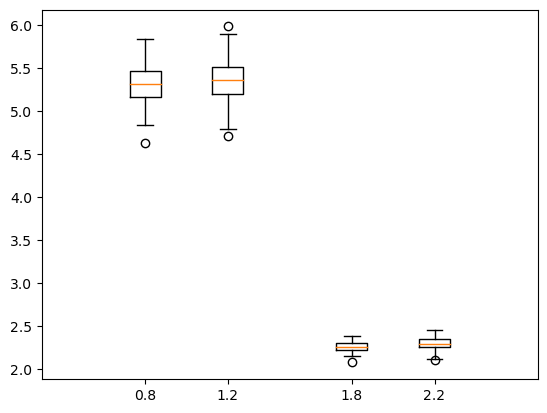

In [1416]:
x = range(1,3)
y = [np.std(x_record[:,0]),np.std(x_record[:,1])]
plt.boxplot(std1,positions=[1.2,2.2])
plt.boxplot(std2,positions=[0.8,1.8])